<a href="https://colab.research.google.com/github/dasariteena/BDA-Assignment-2/blob/main/bda_assignment_02_094.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Build a Classification Model with Spark with a dataset of your choice

In [1]:
#CHOSEN IRIS DATASET

In [3]:
import os

# Download and extract Spark
!apt-get update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz

# Set environment variables for Spark and Java
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

!pip install -q findspark

import findspark
findspark.init()

from pyspark.sql import SparkSession

# Create SparkSession
spark = SparkSession.builder.appName("BDA_Assignment").getOrCreate()
print("Spark Installed Successfully!")

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,015 kB]
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,533 kB]
Get:13 http://security.ubuntu.

+------+----+-----+-----+-------+--------+
|Pclass| Age|SibSp|Parch|   Fare|Survived|
+------+----+-----+-----+-------+--------+
|     3|22.0|    1|    0|   7.25|       0|
|     1|38.0|    1|    0|71.2833|       1|
|     3|26.0|    0|    0|  7.925|       1|
|     1|35.0|    1|    0|   53.1|       1|
|     3|35.0|    0|    0|   8.05|       0|
|     1|54.0|    0|    0|51.8625|       0|
|     3| 2.0|    3|    1| 21.075|       0|
|     3|27.0|    0|    2|11.1333|       1|
|     2|14.0|    1|    0|30.0708|       1|
|     3| 4.0|    1|    1|   16.7|       1|
+------+----+-----+-----+-------+--------+
only showing top 10 rows

+--------------------+-----+----------+
|            features|label|prediction|
+--------------------+-----+----------+
|(5,[0,1],[1.0,40.0])|    0|       1.0|
|(5,[0,1],[3.0,49.0])|    0|       0.0|
|[1.0,2.0,1.0,2.0,...|    0|       1.0|
|[1.0,16.0,0.0,0.0...|    1|       1.0|
|[1.0,18.0,0.0,2.0...|    1|       1.0|
|[1.0,19.0,0.0,0.0...|    1|       1.0|
|[1.0,21.0,0

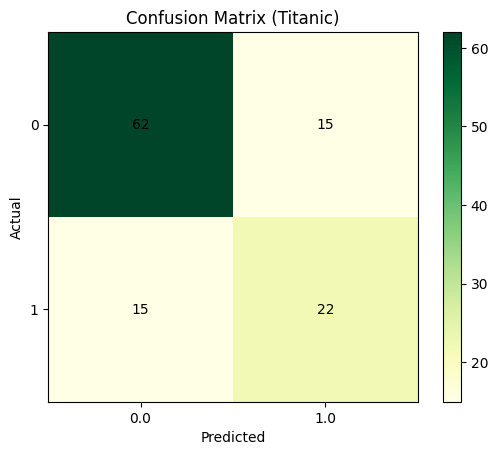

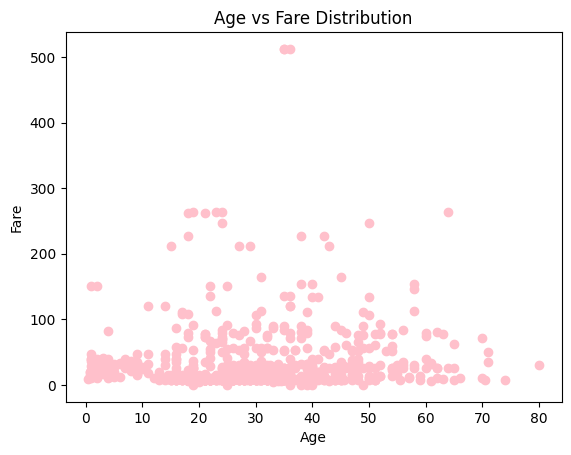

In [4]:
import requests


url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
local_file_path = "titanic.csv"


response = requests.get(url)
response.raise_for_status()

with open(local_file_path, "wb") as f:
    f.write(response.content)

df = spark.read.csv(local_file_path, header=True, inferSchema=True)


df = df.select("Pclass","Age","SibSp","Parch","Fare","Survived").dropna()

df.show(10)


from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Pclass","Age","SibSp","Parch","Fare"],
    outputCol="features"
)

data = assembler.transform(df).select("features","Survived")
data = data.withColumnRenamed("Survived","label")


from pyspark.ml.classification import LogisticRegression

train, test = data.randomSplit([0.8,0.2], seed=42)

model = LogisticRegression().fit(train)

pred = model.transform(test)

pred.select("features","label","prediction").show()


from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator()

print("Accuracy:", evaluator.setMetricName("accuracy").evaluate(pred))
print("Precision:", evaluator.setMetricName("weightedPrecision").evaluate(pred))
print("Recall:", evaluator.setMetricName("weightedRecall").evaluate(pred))
print("F1 Score:", evaluator.setMetricName("f1").evaluate(pred))


import matplotlib.pyplot as plt
import pandas as pd


pdf = pred.select("label", "prediction").toPandas()


cm = pd.crosstab(pdf['label'], pdf['prediction'])

print("\nConfusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, cmap='YlGn')
plt.title("Confusion Matrix (Titanic)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(len(cm.columns)), cm.columns)
plt.yticks(range(len(cm.index)), cm.index)

for i in range(len(cm.index)):
    for j in range(len(cm.columns)):
        plt.text(j, i, cm.iloc[i, j], ha='center', va='center')

plt.colorbar()
plt.show()


pdf_full = df.toPandas()

plt.figure()
plt.scatter(pdf_full["Age"], pdf_full["Fare"], color='pink')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare Distribution")
plt.show()

In [5]:
#Build a Clustering Model with Spark with a dataset of your choice

+-------+------+-----+----+-------+------+----------------+----------+
|Channel|Region|Fresh|Milk|Grocery|Frozen|Detergents_Paper|Delicassen|
+-------+------+-----+----+-------+------+----------------+----------+
|      2|     3|12669|9656|   7561|   214|            2674|      1338|
|      2|     3| 7057|9810|   9568|  1762|            3293|      1776|
|      2|     3| 6353|8808|   7684|  2405|            3516|      7844|
|      1|     3|13265|1196|   4221|  6404|             507|      1788|
+-------+------+-----+----+-------+------+----------------+----------+
only showing top 4 rows

Cluster Centers:
[7390.958, 4439.769, 6292.196, 2495.534, 2238.653, 1158.448]
[32768.013, 4827.68, 5723.147, 5535.92, 1074.12, 2066.64]
[11849.179, 24717.107, 33887.714, 3409.321, 15459.714, 4483.857]

+-----+-----+----------+
|Fresh| Milk|prediction|
+-----+-----+----------+
|12669| 9656|         0|
| 7057| 9810|         0|
| 6353| 8808|         0|
|13265| 1196|         0|
|22615| 5410|         1|
| 941

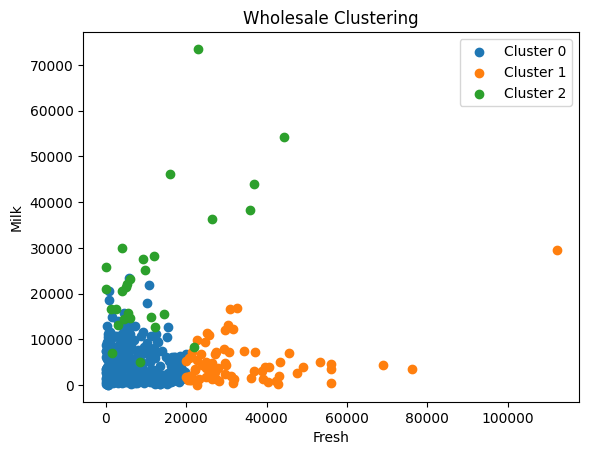

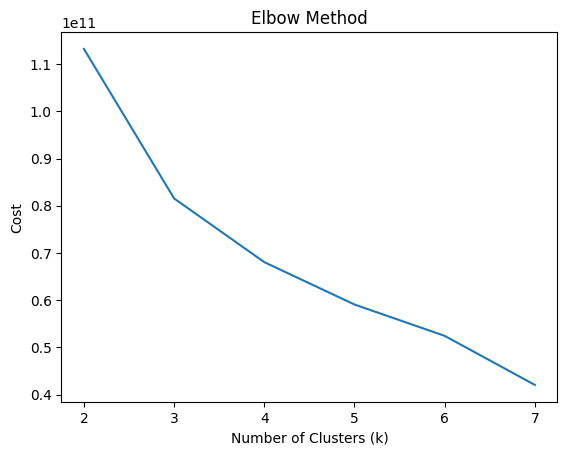

In [6]:
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
local_file_path = "wholesale-customers.csv"


response = requests.get(url)
response.raise_for_status()

with open(local_file_path, "wb") as f:
    f.write(response.content)

df = spark.read.csv(local_file_path, header=True, inferSchema=True)

df.show(4)


from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Fresh","Milk","Grocery","Frozen","Detergents_Paper","Delicassen"],
    outputCol="features"
)
data = assembler.transform(df)


from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=3, seed=1)
model = kmeans.fit(data)

# Print cluster centers after the model is fitted
print("Cluster Centers:")
for center in model.clusterCenters():
    print([round(float(x), 3) for x in center])
print()

pred = model.transform(data)
pred.select("Fresh","Milk","prediction").show()


from pyspark.ml.evaluation import ClusteringEvaluator

silhouette = ClusteringEvaluator().evaluate(pred)
print("Silhouette Score:", silhouette)


import matplotlib.pyplot as plt
import pandas as pd

pdf = pred.select("Fresh","Milk","prediction").toPandas()

plt.figure()
for c in sorted(pdf['prediction'].unique()):
    subset = pdf[pdf['prediction']==c]
    plt.scatter(subset["Fresh"], subset["Milk"], label=f"Cluster {c}")

plt.xlabel("Fresh")
plt.ylabel("Milk")
plt.title("Wholesale Clustering")
plt.legend()
plt.show()


cost = []
k_values = range(2, 8) # Changed range to start from 2

for k in k_values:
    km = KMeans(k=k, seed=1)
    m = km.fit(data)
    cost.append(m.summary.trainingCost)

plt.figure()
plt.plot(k_values, cost)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Cost")
plt.title("Elbow Method")
plt.show()

In [7]:
#Build a Recommendation Engine with Spark with a dataset of your choice

In [8]:
from pyspark.sql import Row

data = [
    Row(user=1, item=101, rating=5),
    Row(user=1, item=102, rating=3),
    Row(user=1, item=103, rating=4),
    Row(user=2, item=101, rating=4),
    Row(user=2, item=102, rating=2),
    Row(user=2, item=103, rating=5),
    Row(user=3, item=101, rating=1),
    Row(user=3, item=102, rating=5),
    Row(user=3, item=103, rating=4),
    Row(user=4, item=101, rating=3),
    Row(user=4, item=102, rating=4),
    Row(user=4, item=103, rating=5),
    Row(user=2, item=101, rating=4),
    Row(user=2, item=102, rating=2),
    Row(user=2, item=103, rating=5),
    Row(user=3, item=101, rating=1),
    Row(user=3, item=102, rating=5),
    Row(user=3, item=103, rating=4),
]

ratings_df = spark.createDataFrame(data)
ratings_df.show()

+----+----+------+
|user|item|rating|
+----+----+------+
|   1| 101|     5|
|   1| 102|     3|
|   1| 103|     4|
|   2| 101|     4|
|   2| 102|     2|
|   2| 103|     5|
|   3| 101|     1|
|   3| 102|     5|
|   3| 103|     4|
|   4| 101|     3|
|   4| 102|     4|
|   4| 103|     5|
|   2| 101|     4|
|   2| 102|     2|
|   2| 103|     5|
|   3| 101|     1|
|   3| 102|     5|
|   3| 103|     4|
+----+----+------+



In [9]:
from pyspark.ml.recommendation import ALS

In [10]:
als = ALS(
    userCol="user",
    itemCol="item",
    ratingCol="rating",
    nonnegative=True,
    implicitPrefs=False,
    coldStartStrategy="drop"
)

model = als.fit(ratings_df)

+----+----+------+----------+
|user|item|rating|prediction|
+----+----+------+----------+
|   1| 101|     5| 4.6407585|
|   1| 102|     3|  2.882164|
|   1| 103|     4|   4.15598|
|   3| 101|     1| 1.1225673|
|   3| 102|     5|  4.779516|
|   3| 103|     4| 3.9310286|
|   2| 101|     4|   3.91367|
|   2| 102|     2| 2.1259303|
|   2| 103|     5| 4.7902813|
|   3| 101|     1| 1.1225673|
|   3| 102|     5|  4.779516|
|   3| 103|     4| 3.9310286|
|   4| 101|     3| 2.9862764|
|   4| 102|     4|  3.927591|
|   4| 103|     5|  4.879169|
|   2| 101|     4|   3.91367|
|   2| 102|     2| 2.1259303|
|   2| 103|     5| 4.7902813|
+----+----+------+----------+



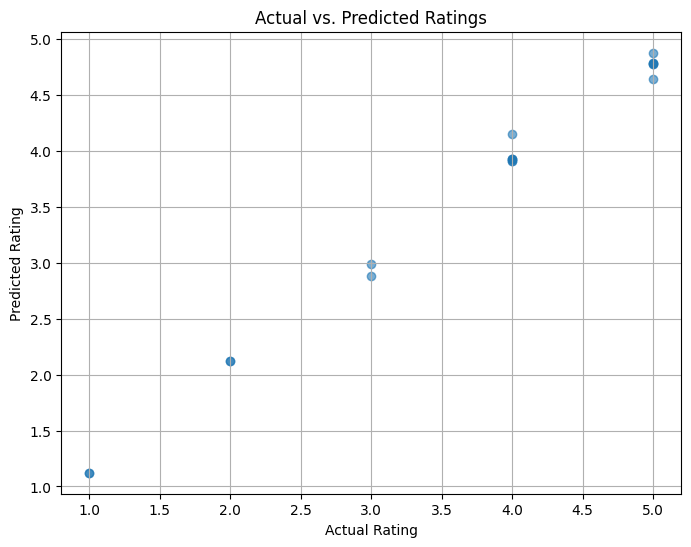

In [11]:
predictions = model.transform(ratings_df)
predictions.show()

import matplotlib.pyplot as plt
import pandas as pd

# Convert Spark DataFrame to Pandas DataFrame for plotting
predictions_pdf = predictions.select("rating", "prediction").toPandas()

plt.figure(figsize=(8, 6))
plt.scatter(predictions_pdf["rating"], predictions_pdf["prediction"], alpha=0.6)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs. Predicted Ratings")
plt.grid(True)
plt.show()